# Tractor VIS-prior photometry versus JAISP mixture priors

This comparison imports the actual [Nima Chartab Euclid forced-photometry implementation](https://github.com/NimaChartab/euclid-forced-photometry/blob/a6bde3d405fda2af980d898fc06790312d8f1c9c/notebooks/01_multiband_forced_photometry.ipynb). Its unchanged Python package is vendored with its license and commit identifier. **These results are controlled simulations, not a real MER catalog comparison.**

All methods see the same 128 two-source scenes (256 sources), native pixels, masks, PSF widths, and known positions. The primary requested comparison is VIS → NISP Y/J/H; the same VIS profiles are also measured in Rubin ugrizy, giving all ten bands.

**Adaptations from the upstream notebook:** use the upstream full model-selection ladder (point, simple exponential, exponential, de Vaucouleurs, composite, guarded Sérsic) while fixing positions throughout; fit the entire supplied group with nearest-source scoring segments within 1.5 arcsec instead of SEP-selected membership; use the existing Gaussian PSFs rather than survey PSF stamps. VIS profile fitting estimates background from pixels beyond 4 arcsec of all sources. Final band fluxes use Tractor-rendered fixed profiles in a signed joint least-squares fit with free constant background and full blend covariance. Upstream's frozen-sky and conditional single-template error conventions are therefore not used.

The mixture methods can adjust profiles per band; the Tractor baseline holds the VIS morphology fixed. Consequently this compares **photometry pipelines**, not only the foundation representation. The orange image-prior control is essential for attributing any improvement to foundation features.

No catalog flux labels or simulated truth shapes initialize the Tractor fit. Input amplitudes come from the noisy VIS image. Regenerated simulation truth is checked against every saved reference flux before fitting. No test-driven tuning of the upstream profile ladder is performed.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'models/photometry/self_supervised').is_dir())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
RUN = ROOT / 'models/photometry/self_supervised/runs/q1_mixture_calibrated'
OUT = RUN / 'tractor_comparison'
protocol = json.loads((OUT / 'protocol.json').read_text())
assert json.loads((OUT / 'failures.json').read_text()) == []
print('Upstream commit:', protocol['upstream']['commit'])
print('Scenes:', protocol['n_scenes'])
from models.photometry.self_supervised.tractor_report import make_report
stats, paired, figures = make_report(RUN)


Upstream commit: a6bde3d405fda2af980d898fc06790312d8f1c9c
Scenes: 128


## Photometry offset versus magnitude

Purple is Tractor with VIS-fitted profiles; orange is the mixture model with a VIS-image prior; blue uses the foundation prior. Curves are 51-source running medians with the 16th–84th percentile distribution shaded. Magnitude curves use the identical common-positive subset; flux-error plots retain signed measurements. Positive magnitude error means too faint.

Horizontal axes remain **instrumental magnitudes**: native-flux AB zero points were not preserved in the cached tiles. No arbitrary shift or 20-AB-mag selection is applied.

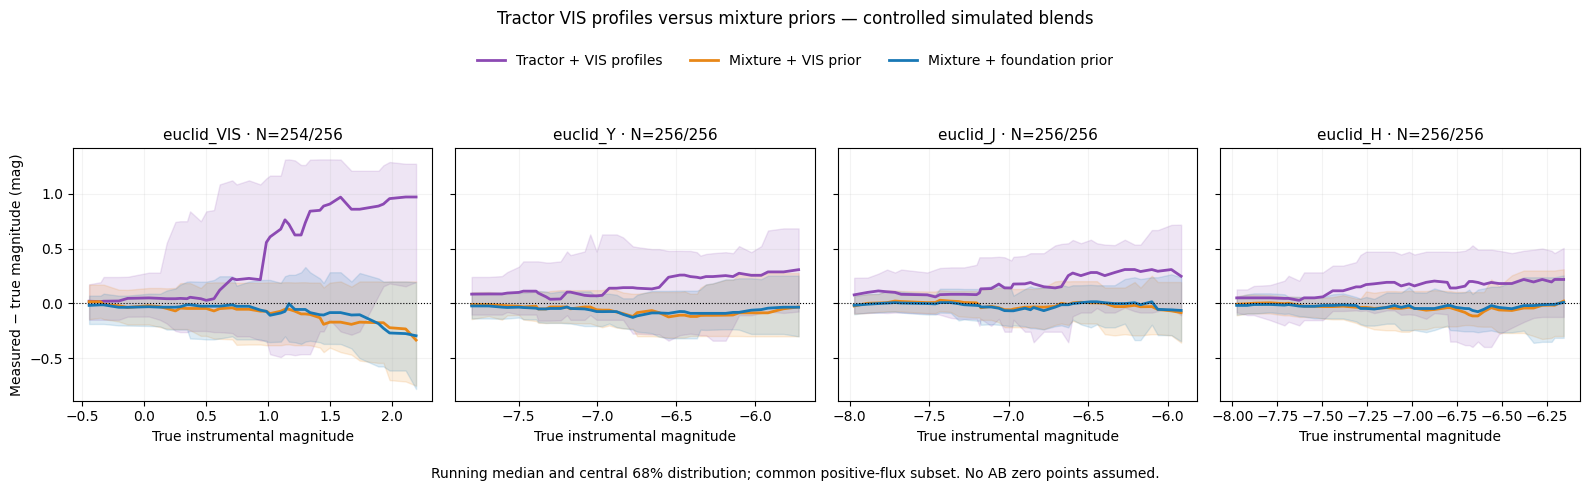

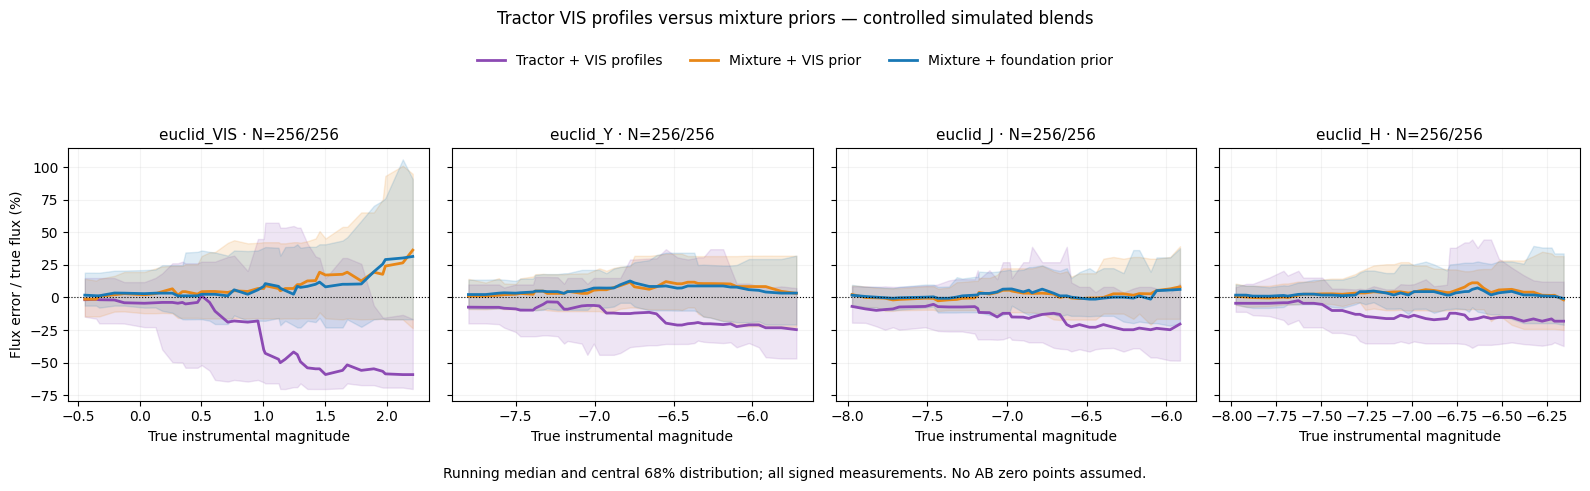

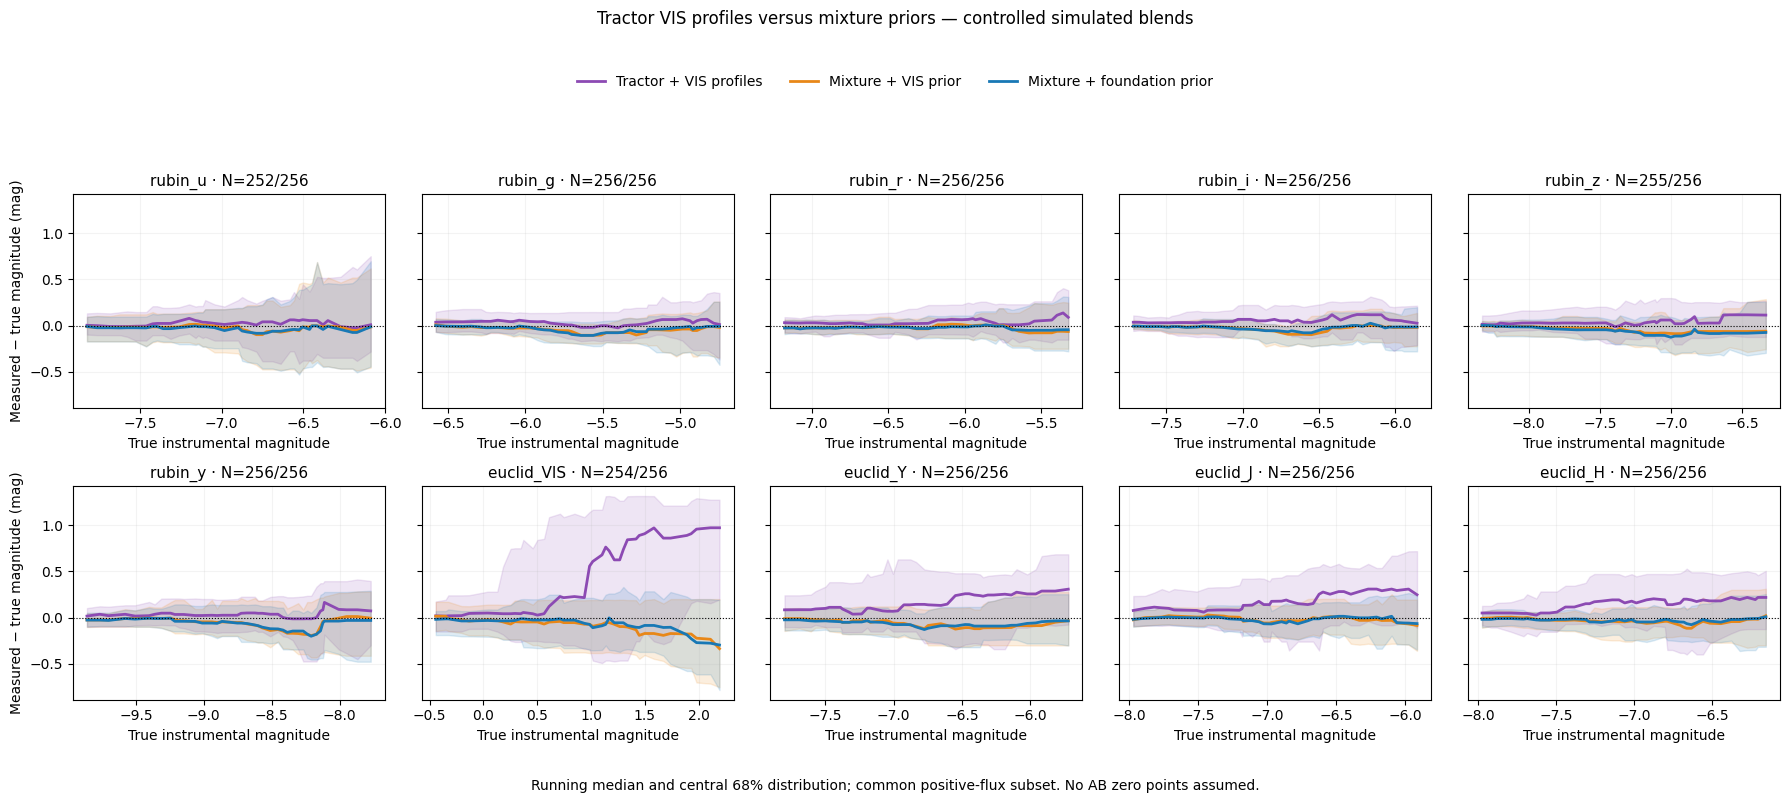

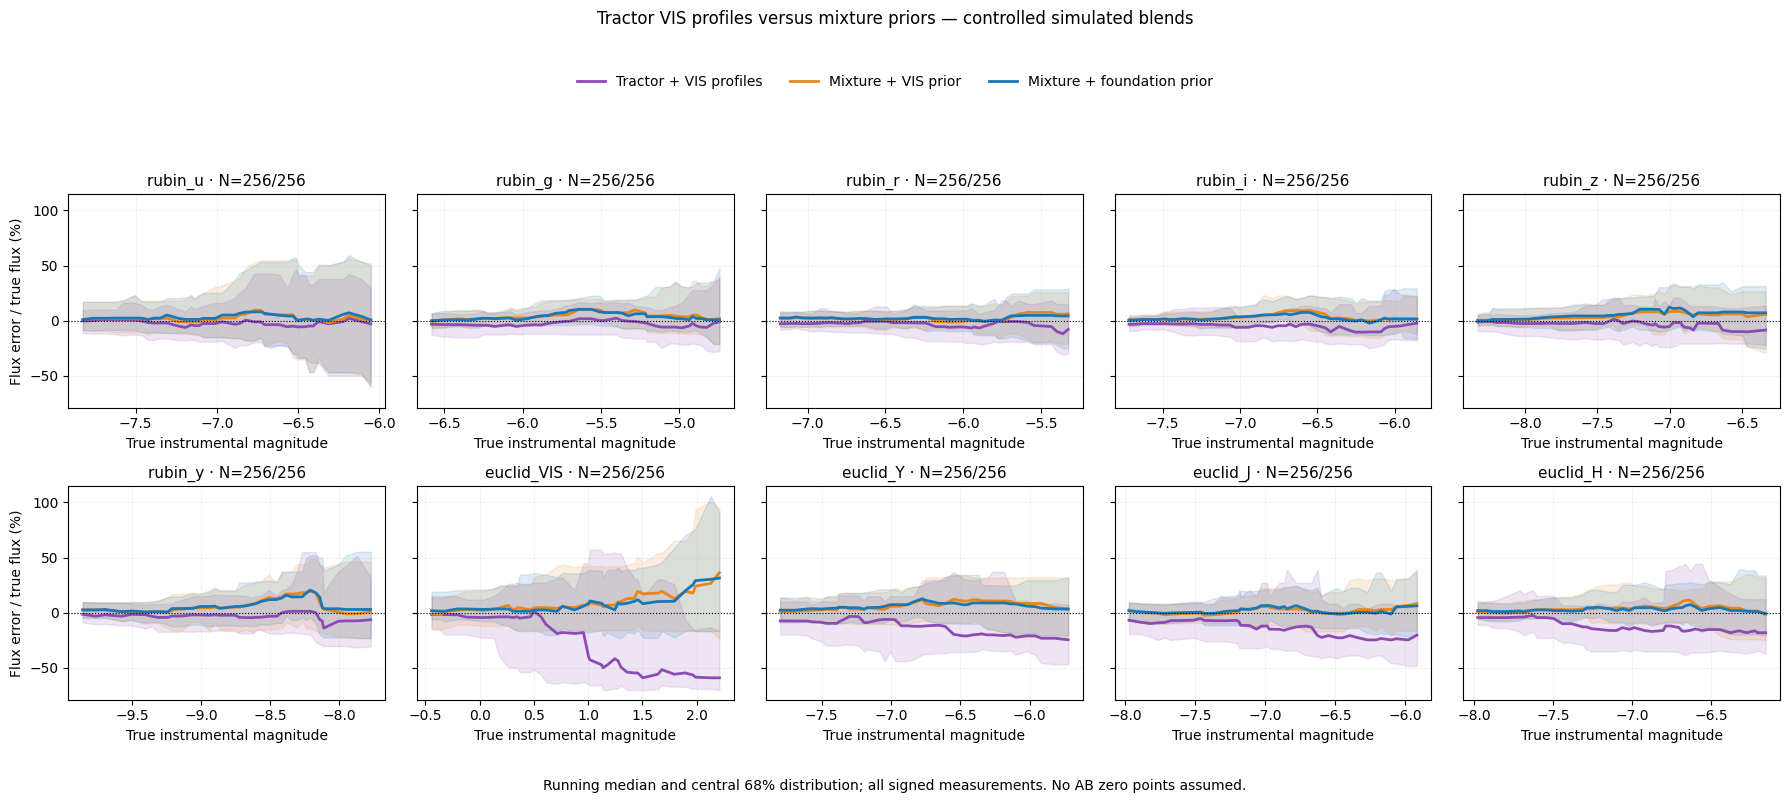

,band,total,common_positive
0,rubin_u,256,252
1,rubin_g,256,256
2,rubin_r,256,256
3,rubin_i,256,256
4,rubin_z,256,255
5,rubin_y,256,256
6,euclid_VIS,256,254
7,euclid_Y,256,256
8,euclid_J,256,256
9,euclid_H,256,256


In [2]:
# Euclid first, then all ten bands; close figures after display.
for i in [2, 3, 0, 1]:
    display(figures[i])
    plt.close(figures[i])
display(pd.read_csv(OUT / 'magnitude_selection.csv'))

## Signed flux accuracy and paired uncertainty

Median absolute fractional flux error uses every source, including nonpositive estimates. The paired bootstrap resamples complete blends, retaining both sources and all bands together (2,000 draws). Negative differences favor the indicated mixture model over Tractor. These confidence intervals describe this finite simulated population, not robustness to PSF errors or realistic morphology.

In [3]:
accuracy = stats.pivot(index='band', columns='model', values='median_absolute_error_percent')
display(accuracy.round(2))
print('NISP mean of per-band median absolute percentage errors:')
display(accuracy.loc[['euclid_Y','euclid_J','euclid_H']].mean().round(2))
display(paired[paired.band.isin(['NISP_YJH','all_bands'])].round(3))
profiles = pd.read_csv(OUT / 'tractor_fluxes.csv').query("band == 'euclid_VIS'").profile.value_counts()
display(profiles.rename('source_count'))

NISP mean of per-band median absolute percentage errors:


model,foundation,image,tractor_vis
band,,,
euclid_H,9.31,10.00,18.16
euclid_J,9.65,9.37,20.12
euclid_VIS,19.01,18.09,44.05
euclid_Y,11.90,12.04,21.10
rubin_g,7.65,8.36,9.36
rubin_i,5.90,6.91,9.46
rubin_r,7.19,7.31,9.14
rubin_u,15.03,15.33,13.19
rubin_y,12.35,13.55,12.14


model
foundation     10.28
image          10.47
tractor_vis    19.79
dtype: float64

,model,band,difference_pp,ci_low_pp,ci_high_pp
10,foundation,NISP_YJH,-9.507,-12.706,-6.317
11,foundation,all_bands,-5.988,-7.877,-3.999
22,image,NISP_YJH,-9.322,-12.383,-6.292
23,image,all_bands,-5.819,-7.665,-3.967


profile
PointSource             127
ExpGalaxy                63
FixedCompositeGalaxy     40
DevGalaxy                16
SimpleGalaxy             10
Name: source_count, dtype: int64

## Reproduce

From the JAISP root, set up the isolated runtime with `bash models/photometry/self_supervised/setup_tractor.sh python3.11`. Then:

```bash
python -m models.photometry.self_supervised.tractor_export --run models/photometry/self_supervised/runs/q1_mixture_calibrated
OPENBLAS_NUM_THREADS=1 OMP_NUM_THREADS=1 models/photometry/self_supervised/runs/tractor_env/bin/python -m models.photometry.self_supervised.tractor_compare --run models/photometry/self_supervised/runs/q1_mixture_calibrated --workers 4
models/photometry/self_supervised/runs/tractor_env/bin/python -m unittest models.photometry.self_supervised.tests.test_tractor_bridge
```

Export and reporting use the existing JAISP environment; fitting uses the separate Tractor environment. The two integration tests check signed blended-flux recovery, background, covariance and invalid-pixel masking; they do not establish astronomical accuracy.

For a survey-data comparison, both methods still need the same original science/variance/flag products, spatial PSFs, photometric zero points, source list and footprint. MER template-fit measurements are a useful cross-check, not independent truth. Known positions/PSFs in this experiment do not test the detection or astrometry heads.